## Aniket Hinge

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf

# Defining 10 Indian stocks from 3 Sectors
# Sector 1: IT (TCS, Infosys, Wipro)
# Sector 2: Finance (HDFC Bank, ICICI Bank, SBI, Axis Bank)
# Sector 3: Consumer/Auto (Reliance, HUL, Tata Motors)
tickers = [
    "TCS.NS",
    "INFY.NS",
    "WIPRO.NS",
    
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "AXISBANK.NS",
    
    "RELIANCE.NS",
    "HINDUNILVR.NS",
    "TATAMOTORS.NS"
]

# Download price data
prices = yf.download(
    tickers,
    start="2017-01-01",
    end="2019-12-31",
    auto_adjust=True
)["Close"]

# Compute daily returns
daily_returns = prices.pct_change().dropna()

# Annualized statistics
# 252 is the standard number of trading days in a year
mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

# Display data
mean_returns_table = (
    mean_returns
    .to_frame(name="Expected Annual Return")
    .round(4)
)

cov_matrix_table = cov_matrix.round(4)

[*********************100%***********************]  10 of 10 completed


### The Mathematical Problem Definition
For the above 10 stocks (TCS, HDFC, Reliance, etc.), the Markowitz Mean-Variance Optimization problem is defined as finding the vector of 10 weights ($\mathbf{w}$) that minimizes portfolio risk for a given target return. 

Variables from the code: <br>
1. $\mathbf{w}$: A vector of 10 weights $[w_{TCS}, w_{INFY}, \dots, w_{TATA}]$. 
2. $\Sigma$: The cov_matrix.
3. $\mu$: The mean_returns vector.

The Optimization Setup:
$$\begin{aligned}
& \underset{\mathbf{w}}{\text{minimize}} & & \frac{1}{2} \mathbf{w}^T (\text{cov\_matrix}) \mathbf{w} \\
& \text{subject to} & & \sum_{i=1}^{10} w_i = 1 \quad (\text{Budget Constraint}) \\
& & & w_i \geq 0 \quad (\text{No Short Selling})
\end{aligned}$$

### Return Calculation

Daily returns are computed using percentage price changes:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$


### Mean Returns

Mean returns and covariance is computed using the annual expected return and covariance:

$$
\mu = 252 \cdot \mathbb{E}[r_t]
$$

$$
\Sigma = 252 \cdot \text{Cov}(r_t)
$$


In [18]:
print(mean_returns_table)

               Expected Annual Return
Ticker                               
AXISBANK.NS                    0.2217
HDFCBANK.NS                    0.2826
HINDUNILVR.NS                  0.3255
ICICIBANK.NS                   0.3441
INFY.NS                        0.1954
RELIANCE.NS                    0.3999
SBIN.NS                        0.1687
TATAMOTORS.NS                 -0.2449
TCS.NS                         0.2612
WIPRO.NS                       0.1431


In [19]:
df = pd.DataFrame(cov_matrix_table)
df

Ticker,AXISBANK.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,SBIN.NS,TATAMOTORS.NS,TCS.NS,WIPRO.NS
Ticker,,,,,,,,,,
AXISBANK.NS,0.0788,0.0101,0.0100,0.0443,0.0016,0.0160,0.0435,0.0307,-0.0013,-0.0006
HDFCBANK.NS,0.0101,0.0281,0.0105,0.0101,0.0001,0.0088,0.0115,0.0122,0.0012,0.0026
HINDUNILVR.NS,0.0100,0.0105,0.0376,0.0118,0.0018,0.0080,0.0125,0.0150,0.0050,0.0060
ICICIBANK.NS,0.0443,0.0101,0.0118,0.0862,-0.0007,0.0166,0.0646,0.0305,-0.0025,0.0019
INFY.NS,0.0016,0.0001,0.0018,-0.0007,0.0623,0.0029,0.0050,0.0067,0.0225,0.0130
RELIANCE.NS,0.0160,0.0088,0.0080,0.0166,0.0029,0.0685,0.0187,0.0286,0.0018,0.0048
SBIN.NS,0.0435,0.0115,0.0125,0.0646,0.0050,0.0187,0.1185,0.0403,-0.0002,0.0040
TATAMOTORS.NS,0.0307,0.0122,0.0150,0.0305,0.0067,0.0286,0.0403,0.1791,0.0053,0.0090
TCS.NS,-0.0013,0.0012,0.0050,-0.0025,0.0225,0.0018,-0.0002,0.0053,0.0535,0.0146


## Convex Portfolio Optimization

We will use 

In [26]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

mu = mean_returns .values
Sigma = cov_matrix.values 
n = len(mu)

w = cp.Variable(n) # The weights vector we want to find

# Risk = w.T * Sigma * w
# cp.quad_form(w, Sigma) is the standard way to write quadratic forms in cvxpy
risk_model = cp.quad_form(w, Sigma)

# This finds the absolute lowest risk point on the curve
objective = cp.Minimize(risk_model)
constraints_gmvp = [
    cp.sum(w) == 1,  # Budget constraint
    w >= 0           # No short selling
]

prob = cp.Problem(objective, constraints_gmvp)
prob.solve()

# results
weights = w.value
risk = np.sqrt(prob.value)
ret = mu @ weights

print(f"Min Volatility: {risk:.2%}")
print(f"Min Return:     {ret:.2%}")

Min Volatility: 10.98%
Min Return:     26.37%


In [27]:
print("Optimal Weights:")
for i, ticker in enumerate(tickers):
    print(f"  {ticker}: {weights[i]:.2%}")

Optimal Weights:
  TCS.NS: 5.86%
  INFY.NS: 29.30%
  WIPRO.NS: 14.82%
  HDFCBANK.NS: 4.07%
  ICICIBANK.NS: 10.94%
  SBIN.NS: 7.90%
  AXISBANK.NS: 0.00%
  RELIANCE.NS: 0.00%
  HINDUNILVR.NS: 11.78%
  TATAMOTORS.NS: 15.33%


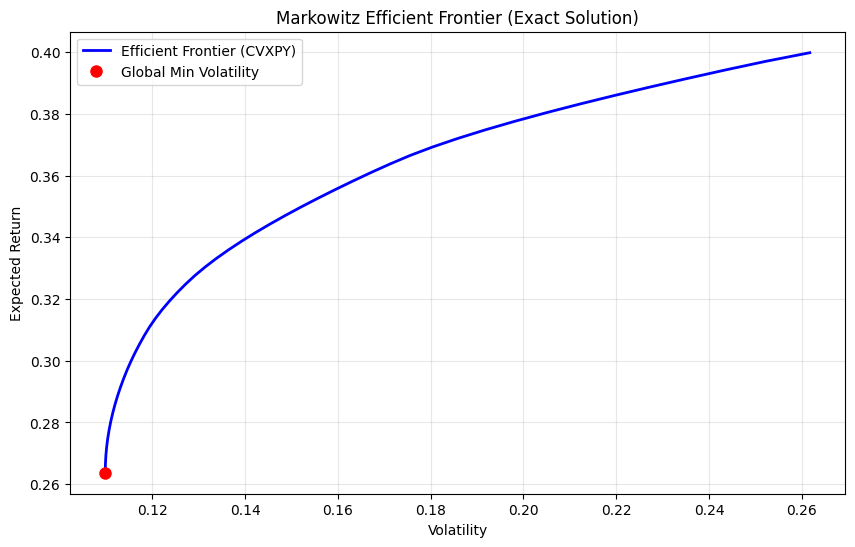

In [40]:
# 1. Setup Variables
w = cp.Variable(n_assets)
risk_model = cp.quad_form(w, Sigma)

# 2. Solve for Global Minimum Variance Portfolio (GMVP)
# We do this first to find the lower bound of the frontier
prob_gmvp = cp.Problem(cp.Minimize(risk_model), [cp.sum(w) == 1, w >= 0])
prob_gmvp.solve()

gmvp_risk = np.sqrt(prob_gmvp.value)
gmvp_ret = w.value @ mu

# 3. Calculate Efficient Frontier
# Iterate from GMVP return up to the maximum asset return
target_returns = np.linspace(gmvp_ret, mu.max(), 50)
efficient_risks = []

for target in target_returns:
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w @ mu >= target
    ]
    
    prob = cp.Problem(cp.Minimize(risk_model), constraints)
    prob.solve()
    
    efficient_risks.append(np.sqrt(prob.value))

# 4. Plot Exact Frontier
plt.figure(figsize=(10, 6))
plt.plot(efficient_risks, target_returns, 'b-', linewidth=2, label='Efficient Frontier (CVXPY)')
plt.plot(gmvp_risk, gmvp_ret, 'ro', markersize=8, label='Global Min Volatility')


plt.title('Markowitz Efficient Frontier (Exact Solution)')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Monte Carlo Method

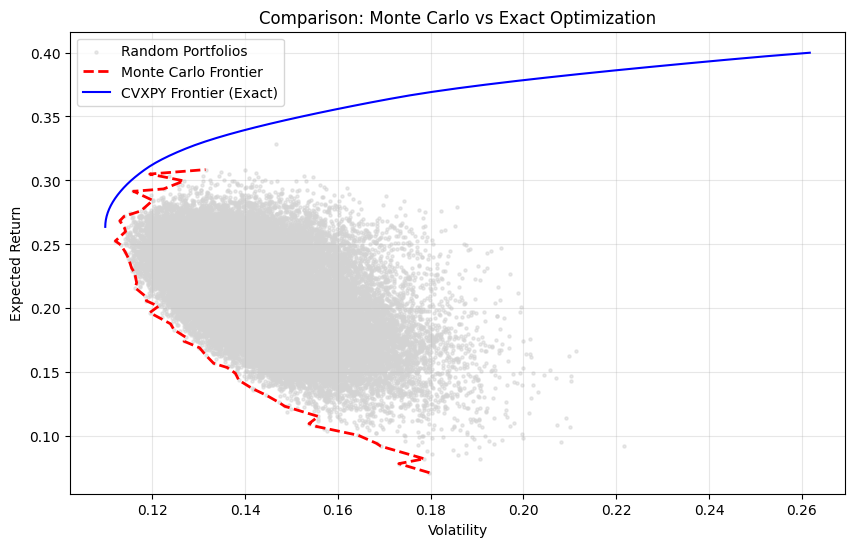

In [41]:
# 1. Simulation Settings
num_portfolios = 50000
results = np.zeros((2, num_portfolios)) # Row 0: Return, Row 1: Volatility
n_assets = len(mu)

np.random.seed(42)

# 2. Generate Random Portfolios
for i in range(num_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    
    results[0, i] = np.dot(weights, mu)
    results[1, i] = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))

mc_df = pd.DataFrame(results.T, columns=['Return', 'Volatility'])

# 3. Extract Minimum Risk Frontier from Simulation
mc_df = mc_df.sort_values(by='Return')
bins = np.linspace(mc_df['Return'].min(), mc_df['Return'].max(), 50)
frontier_mc_vol = []
frontier_mc_ret = []

for i in range(len(bins)-1):
    mask = (mc_df['Return'] >= bins[i]) & (mc_df['Return'] < bins[i+1])
    if mask.any():
        row = mc_df[mask].loc[mc_df[mask]['Volatility'].idxmin()]
        frontier_mc_vol.append(row['Volatility'])
        frontier_mc_ret.append(row['Return'])

# 4. Plot Comparison
plt.figure(figsize=(10, 6))

# Plot Cloud
plt.scatter(mc_df['Volatility'], mc_df['Return'], color='lightgray', alpha=0.5, s=5, label='Random Portfolios')

# Plot Extracted Frontier
plt.plot(frontier_mc_vol, frontier_mc_ret, 'r--', linewidth=2, label='Monte Carlo Frontier')

# Overlay Exact Frontier (from Part 2)
plt.plot(efficient_risks, target_returns, 'b-', linewidth=1.5, label='CVXPY Frontier (Exact)')

plt.title('Comparison: Monte Carlo vs Exact Optimization')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()